# Analysis of Concepts

In [1]:
import torch
import pandas as pd

meta = torch.load("../vi-mtl/cache/metadata-divers_aux.pt")
data = meta["info"]

df = pd.DataFrame.from_dict(data, orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [2]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col.startswith("matched_"):
            n_empty = len(df[df[col].apply(len) == 0])
        else:
            n_empty = df[col].isna().sum()
        print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "matched_instruments_groups",
    "matched_concepts",
    "matched_segments",
    "release_styles",
    "release_genres",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 0 missing (0.00% of total 1295787)
matched_instruments_groups: 798,469 missing (61.62% of total 1295787)
matched_concepts: 238,740 missing (18.42% of total 1295787)
matched_segments: 1,221,462 missing (94.26% of total 1295787)
release_styles: 854,068 missing (65.91% of total 1295787)
release_genres: 854,068 missing (65.91% of total 1295787)

NaN info for DVI dataset
tempo: 0 missing (0.00% of total 446346)
matched_instruments_groups: 291,923 missing (65.40% of total 446346)
matched_concepts: 1,363 missing (0.31% of total 446346)
matched_segments: 436,440 missing (97.78% of total 446346)
release_styles: 4,627 missing (1.04% of total 446346)
release_genres: 4,627 missing (1.04% of total 446346)


## Value Distributions

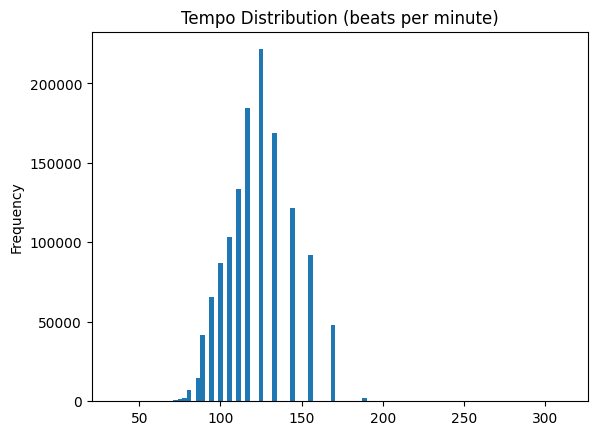

In [3]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=100, title="Tempo Distribution (beats per minute)")
plt.show()


In [4]:
def parse_matched_dict(d):
    if isinstance(d, dict):
        return list({k for sub in d.values() for k in sub.keys()})
    return []

se_concepts = df.matched_concepts.apply(parse_matched_dict)
se_instruments = df.matched_instruments_groups.apply(parse_matched_dict)


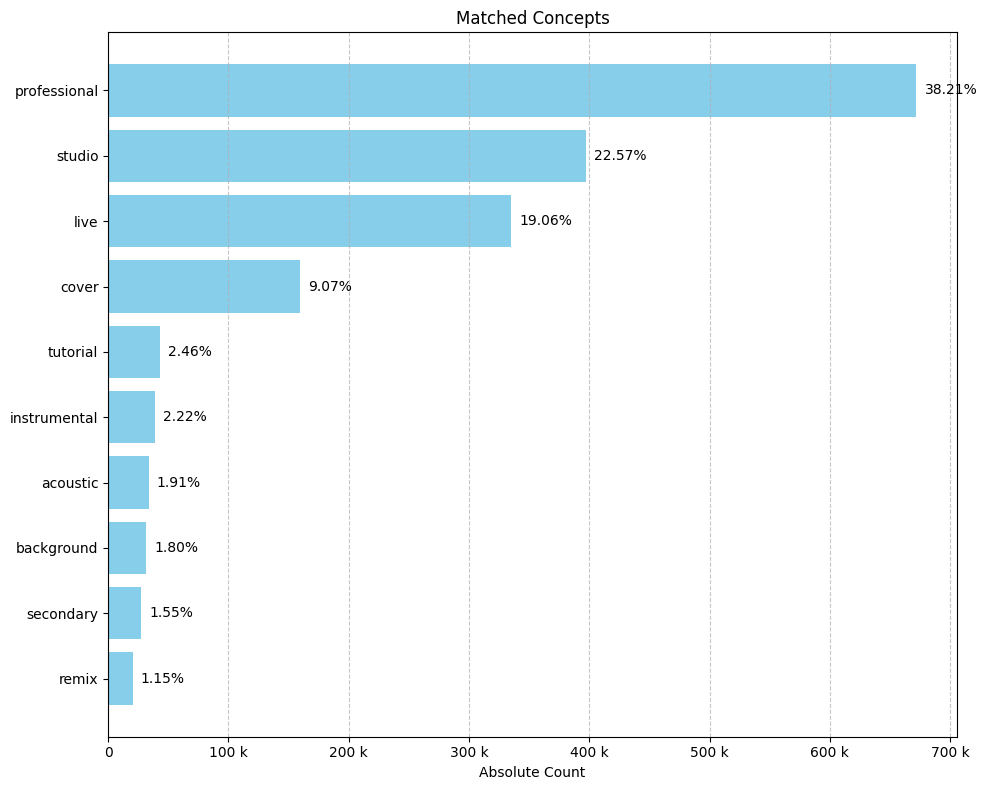

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter


def plot_string_counts_barh(series, label_name, top_n=None, vlines=None):
    """
    Plot a horizontal bar chart of value counts (absolute and relative) from a Series of lists.
    
    Parameters:
        series (pd.Series): Series where each element is a list of strings.
        label_name (str): Title for the plot.
        top_n (int, optional): Show only the top N items.
        vlines (list of int, optional): Add vertical reference lines at these x-values.
    """
    counts = series.explode().value_counts()
    if top_n:
        counts = counts.head(top_n)
    relative = counts / counts.sum()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)
    bars = ax.barh(counts.index, counts.values, color='skyblue')

    # Add relative % labels
    for i, (abs_val, rel_val) in enumerate(zip(counts.values, relative.values)):
        ax.text(abs_val + max(counts.values) * 0.01, i, f"{rel_val:.2%}", va='center')

    # Format x-axis ticks (e.g., 100k instead of 100000)
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))

    # Title and labels
    ax.set_title(f"Matched {label_name}")
    ax.set_xlabel("Absolute Count")
    ax.invert_yaxis()  # Highest at top

    # Add optional vertical reference lines
    if vlines:
        for v in vlines:
            ax.axvline(x=v, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


plot_string_counts_barh(se_concepts, "Concepts",)


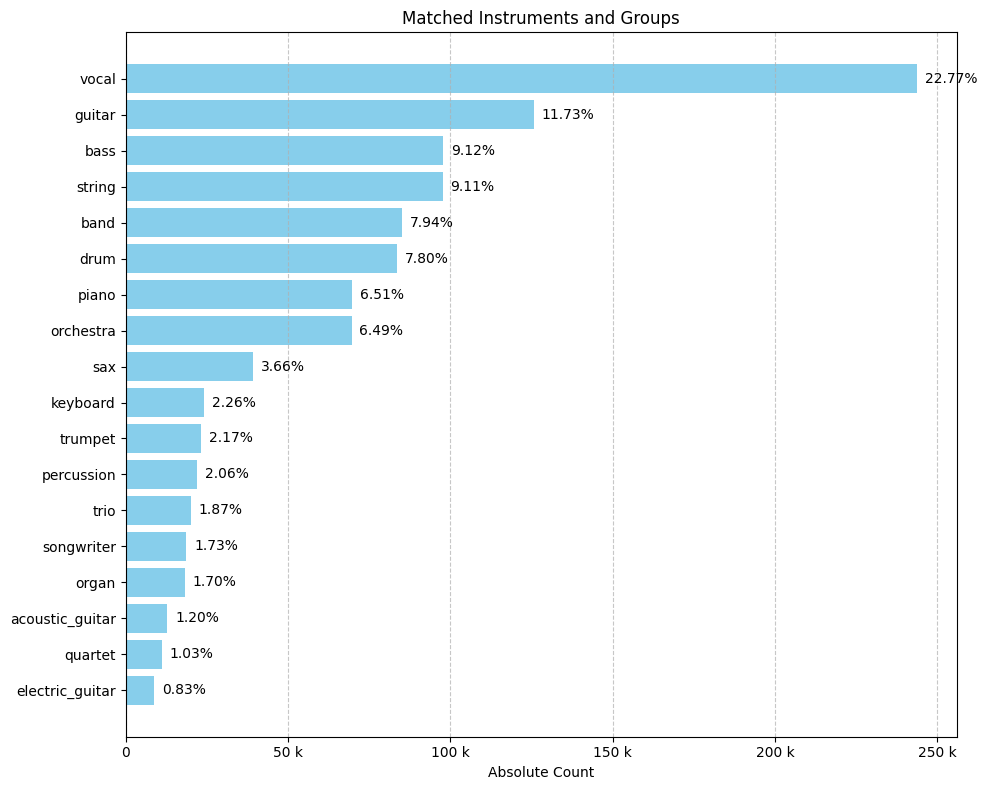

In [19]:
plot_string_counts_barh(se_instruments, "Instruments and Groups",)
